In [1]:
import sys
sys.argv = sys.argv[:1]

import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
from tsbenchmark.data_process import GenerateAnomaly, PrepareDf
from tsbenchmark.metric import ProbTimeDetection, FalseRate
from canari import (
    DataProcess,
    SKF,
)
from tsbenchmark.detector import ProphetDetector, SkfDetector, TranAdDetector, LstmEdDetector


In [2]:
# data_file = "/Users/vuongdai/Desktop/backup_canari/hq_global_data/4-held-out-ts/LGA002EFAPRG910_cleaned.csv"
# data_file = "/Users/vuongdai/Desktop/backup_canari/hq_global_data/4-held-out-ts/test_2_data.csv"
# data_file = "/Users/vuongdai/Desktop/backup_canari/hq_global_data/4-held-out-ts/test_5_data.csv"
data_file = "/Users/vuongdai/Desktop/backup_canari/hq_global_data/4-held-out-ts/test_8_data.csv"

df = pd.read_csv(data_file, skiprows=0, delimiter=",")
df.columns = ["date","values"]
date_time = pd.to_datetime(df["date"])
df = df.drop("date", axis=1)
df.index = date_time
df.index.name = "date_time"

df_dict = {0: df}


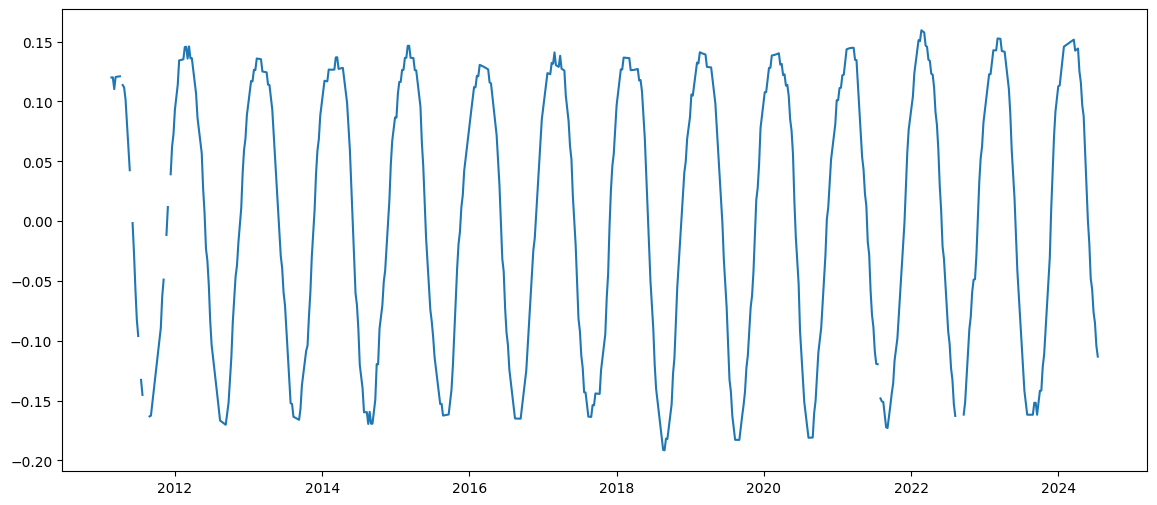

In [3]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df.values)

In [4]:
# -------------------------------------------------------------------#
# # Load anomaly info.
anomaly_info_file = "/Users/vuongdai/GitHub/bm/detrend_data/anomaly_info/anomaly_info.json"
with open(anomaly_info_file, "r") as f:
    anomaly_info = json.load(f)

# -------------------------------------------------------------------#
# # Loop over time series 
anom_result = {}

for ts, df_temp in df_dict.items():
    print("---------------------------")
    print("---------------------------")
    print(f"ts #{ts} ...... ")
    anom_result[ts] = {}

    # Split data into training and test sets; standardize data
    train_split = 0.5
    data_processor = DataProcess(
        data=df_temp,
        time_covariates=["week_of_year"],
        train_split=train_split,
        validation_split=0,
        test_split=1-train_split,
        output_col=[0],
    )
    _train_data, _, _test_data, all_data = data_processor.get_splits()

    # Training data
    train_df = pd.DataFrame(
        data = _train_data["y"],
        index= _train_data["time"],
    )
    train_dict = {0: train_df}
    train_df_interpolate = train_df.interpolate(method="linear")
    train_dict = {0: train_df}
    train_dict_interpolate = {0: train_df_interpolate}

    # Test data: not include training data
    _test_df_no_anom = pd.DataFrame(
        data = _test_data["y"],
        index= _test_data["time"],
    )
    _test_df_no_anom_interpolate = _test_df_no_anom.interpolate(method="linear")
    test_dict_no_anom = {0: _test_df_no_anom}
    test_dict_no_anom_interpolate = {0: _test_df_no_anom_interpolate}

    # Test data: include training data
    _test_df_anom = pd.DataFrame(
        data = all_data["y"],
        index= all_data["time"],
    )
    _test_df_anom_interpolate = _test_df_anom.interpolate(method="linear")
    test_dict_anom = {0: _test_df_anom}
    test_dict_anom_interpolate = {0: _test_df_anom_interpolate}

    # ---------------------------------------------- #
    # # Generate anomalies
    anomaly_info["anomaly_start"] = 0.5
    anomaly_info["anomaly_end"] = 0.8

    test_data_with_anomaly, test_data_anom_info = GenerateAnomaly(
        data=copy.deepcopy(test_dict_anom),
        anomaly_info=anomaly_info,
    )

    test_data_with_anomaly_interpolate, test_data_anom_info = GenerateAnomaly(
        data=copy.deepcopy(test_dict_anom_interpolate),
        anomaly_info=anomaly_info,
    )

    # ----------------------------------------------
    # ---------------------#
    # TSAD comparision

    # -------------------------------------------------------------------#
    # # 1. SKF detector
    anom_result[ts]["skf"] = {}
    anom_result[ts]["skf"]["false_rate"] = {}
    anom_result[ts]["skf"]["prob"] = {}
    anom_result[ts]["skf"]["ttd"] = {}

    skf_models_link = {}
    skf_models_link["seed_1"] = "/Users/vuongdai/GitHub/canari/saved_params/toy_anomaly_detection_tune.pkl"
    # skf_models_link["seed_2"] = "/Users/vuongdai/GitHub/bm/results/BM2_g_1.pkl"

    print("SKF detector ...... ")
    for i, link in skf_models_link.items():
        print(f"    Seed #{i}")
        with open(link, "rb") as f:
            skf_dict = pickle.load(f)
        skf = SKF.load_dict(skf_dict)

        model = SkfDetector(anom_threshold=0.1, model=skf)

        test_cov_no_anom = _test_data["x"].copy()
        score_test = model.get_anomaly_score(data=copy.deepcopy(test_dict_no_anom), covariates=test_cov_no_anom)

        test_cov_anom = all_data["x"].copy()
        score_test_with_anomaly = model.get_anomaly_score(data=copy.deepcopy(test_data_with_anomaly), covariates=test_cov_anom)

        false_rate = FalseRate(score_test)
        prob_detection, time_to_detection = ProbTimeDetection(
            score_test_with_anomaly, 
            test_data_anom_info,
            max_anom_detect_time=pd.Timedelta("2D"))

        anom_result[ts]["skf"]["false_rate"][i] = false_rate[0]
        anom_result[ts]["skf"]["prob"][i] = prob_detection[0]
        anom_result[ts]["skf"]["ttd"][i] = time_to_detection[0]


    # -------------------------------------------------------------------#
    # # 2. Prophet detector
    print("----------------------------------------------")
    print("Prophet detector ...... ")

    anom_result[ts]["prophet"] = {}
    anom_result[ts]["prophet"]["false_rate"] = {}
    anom_result[ts]["prophet"]["prob"] = {}
    anom_result[ts]["prophet"]["ttd"] = {}

    model = ProphetDetector(anom_threshold=0.1)

    score_test = model.get_anomaly_score(data=copy.deepcopy(test_dict_no_anom))

    score_test_with_anomaly = model.get_anomaly_score(data=copy.deepcopy(test_data_with_anomaly))

    false_rate = FalseRate(score_test)
    prob_detection, time_to_detection = ProbTimeDetection(
        score_test_with_anomaly, 
        test_data_anom_info,
        max_anom_detect_time=pd.Timedelta(days=3*365))

    anom_result[ts]["prophet"]["false_rate"] = false_rate[0]
    anom_result[ts]["prophet"]["prob"] = prob_detection[0]
    anom_result[ts]["prophet"]["ttd"] = time_to_detection[0]

    # -------------------------------------------------------------------#
    # # 3. LSTM-ED detector
    print("----------------------------------------------")
    print("LSTM-ED detector ...... ")

    anom_result[ts]["lstmed"] = {}
    anom_result[ts]["lstmed"]["false_rate"] = {}
    anom_result[ts]["lstmed"]["prob"] = {}
    anom_result[ts]["lstmed"]["ttd"] = {}

    for i in ["seed_1","seed_2"]:
        print(f"    Seed #{i}")
        model = LstmEdDetector(sequence_len=52)

        model.train(data=train_df)

        score_test = model.get_anomaly_score(data=copy.deepcopy(test_dict_no_anom_interpolate))

        score_test_with_anomaly = model.get_anomaly_score(data=copy.deepcopy(test_data_with_anomaly_interpolate))

        false_rate = FalseRate(score_test)
        prob_detection, time_to_detection = ProbTimeDetection(
            score_test_with_anomaly, 
            test_data_anom_info,
            max_anom_detect_time=pd.Timedelta(days=3*365))

        anom_result[ts]["lstmed"]["false_rate"][i] = false_rate[0]
        anom_result[ts]["lstmed"]["prob"][i] = prob_detection[0]
        anom_result[ts]["lstmed"]["ttd"][i] = time_to_detection[0]

    # -------------------------------------------------------------------#
    # # 4. TranAD detector
    print("----------------------------------------------")
    print("TranAD detector ...... ")

    anom_result[ts]["tranad"] = {}
    anom_result[ts]["tranad"]["false_rate"] = {}
    anom_result[ts]["tranad"]["prob"] = {}
    anom_result[ts]["tranad"]["ttd"] = {}

    for i in ["seed_1", "seed_2"]:
        print(f"     Seed #{i}")
        model = TranAdDetector(num_epoch=10)

        model.train(data=train_df_interpolate)

        score_test = model.get_anomaly_score(data=copy.deepcopy(test_dict_no_anom_interpolate))

        score_test_with_anomaly = model.get_anomaly_score(data=copy.deepcopy(test_data_with_anomaly))

        false_rate = FalseRate(score_test)
        prob_detection, time_to_detection = ProbTimeDetection(
            score_test_with_anomaly, 
            test_data_anom_info,
            max_anom_detect_time=pd.Timedelta(days=3*365))

        anom_result[ts]["tranad"]["false_rate"][i] = false_rate[0]
        anom_result[ts]["tranad"]["prob"][i] = prob_detection[0]
        anom_result[ts]["tranad"]["ttd"][i] = time_to_detection[0]

    

---------------------------
---------------------------
ts #0 ...... 
SKF detector ...... 
    Seed #seed_1
----------------------------------------------
Prophet detector ...... 
----------------------------------------------
LSTM-ED detector ...... 
    Seed #seed_1
 |========================================| 100.0% Complete, Loss 139.2602
    Seed #seed_2
 |========================================| 100.0% Complete, Loss 152.2576
----------------------------------------------
TranAD detector ...... 
     Seed #seed_1
Epoch 1,	L1 = 1.1813490455456843
Epoch 2,	L1 = 1.1998199506338627
Epoch 3,	L1 = 1.19837235858775
Epoch 4,	L1 = 1.201672428899416
Epoch 5,	L1 = 1.198330456334424
Epoch 6,	L1 = 1.2044762279825203
Epoch 7,	L1 = 1.2014756762849956
Epoch 8,	L1 = 1.1984092692355148
Epoch 9,	L1 = 1.201780676072965
Epoch 10,	L1 = 1.1968180336569132
     Seed #seed_2
Epoch 1,	L1 = 1.5592440866943618
Epoch 2,	L1 = 1.5894891420150643
Epoch 3,	L1 = 1.6031308922108767
Epoch 4,	L1 = 1.5999607846707848

In [5]:
# Results ts 1
anom_result[0]["prophet"]

{'false_rate': 0.0,
 'prob': {'level': {'0.45': 1.0, '-0.45': 1.0, '0.1': 0.4, '-0.1': 0.0},
  'trend': {'0.05': 1.0, '-0.05': 1.0, '0.1': 0.9, '-0.1': 1.0}},
 'ttd': {'level': {'0.45': Timedelta('211 days 09:36:00'),
   '-0.45': Timedelta('212 days 19:12:00'),
   '0.1': Timedelta('156 days 02:24:00'),
   '-0.1': Timedelta('0 days 00:00:00')},
  'trend': {'0.05': Timedelta('116 days 04:48:00'),
   '-0.05': Timedelta('96 days 14:24:00'),
   '0.1': Timedelta('98 days 00:00:00'),
   '-0.1': Timedelta('96 days 14:24:00')}}}

In [6]:
anom_result[0]["lstmed"]

{'false_rate': {'seed_1': 0.0, 'seed_2': 0.8970528039295947},
 'prob': {'seed_1': {'level': {'0.45': 0.6,
    '-0.45': 0.5,
    '0.1': 0.0,
    '-0.1': 0.0},
   'trend': {'0.05': 1.0, '-0.05': 1.0, '0.1': 1.0, '-0.1': 1.0}},
  'seed_2': {'level': {'0.45': 1.0, '-0.45': 0.2, '0.1': 0.0, '-0.1': 0.0},
   'trend': {'0.05': 1.0, '-0.05': 1.0, '0.1': 1.0, '-0.1': 1.0}}},
 'ttd': {'seed_1': {'level': {'0.45': Timedelta('476 days 00:00:00'),
    '-0.45': Timedelta('46 days 21:36:00'),
    '0.1': Timedelta('0 days 00:00:00'),
    '-0.1': Timedelta('0 days 00:00:00')},
   'trend': {'0.05': Timedelta('131 days 14:24:00'),
    '-0.05': Timedelta('80 days 12:00:00'),
    '0.1': Timedelta('86 days 19:12:00'),
    '-0.1': Timedelta('17 days 12:00:00')}},
  'seed_2': {'level': {'0.45': Timedelta('131 days 14:24:00'),
    '-0.45': Timedelta('36 days 09:36:00'),
    '0.1': Timedelta('0 days 00:00:00'),
    '-0.1': Timedelta('0 days 00:00:00')},
   'trend': {'0.05': Timedelta('125 days 07:12:00'),
    '

In [7]:
anom_result[0]["tranad"]

{'false_rate': {'seed_1': 1.0465616045845272, 'seed_2': 1.943614408514122},
 'prob': {'seed_1': {'level': {'0.45': 0.1,
    '-0.45': 1.0,
    '0.1': 0.7,
    '-0.1': 1.0},
   'trend': {'0.05': 1.0, '-0.05': 1.0, '0.1': 1.0, '-0.1': 1.0}},
  'seed_2': {'level': {'0.45': 0.0, '-0.45': 1.0, '0.1': 1.0, '-0.1': 1.0},
   'trend': {'0.05': 1.0, '-0.05': 1.0, '0.1': 1.0, '-0.1': 1.0}}},
 'ttd': {'seed_1': {'level': {'0.45': Timedelta('0 days 00:00:00'),
    '-0.45': Timedelta('72 days 02:24:00'),
    '0.1': Timedelta('403 days 21:36:00'),
    '-0.1': Timedelta('105 days 00:00:00')},
   'trend': {'0.05': Timedelta('272 days 07:12:00'),
    '-0.05': Timedelta('94 days 12:00:00'),
    '0.1': Timedelta('145 days 14:24:00'),
    '-0.1': Timedelta('60 days 04:48:00')}},
  'seed_2': {'level': {'0.45': Timedelta('0 days 00:00:00'),
    '-0.45': Timedelta('213 days 12:00:00'),
    '0.1': Timedelta('518 days 16:48:00'),
    '-0.1': Timedelta('319 days 21:36:00')},
   'trend': {'0.05': Timedelta('203 da